In [1]:
# ==========================================
# Step 1: Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (mean_absolute_error,root_mean_squared_error,r2_score)

# Plot Style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Part 1: Data Exploration 
# Task 1
# Load the dataset.
df = pd.read_csv("oil_sales_assignment_dataset.csv")
print("Dataset Loaded Successfully.")
print("\n")
# Display
# first five rows
print("===================================Head===================================")
print(df.head())
print("\n")

# last five rows
print("===================================Tail===================================")
print(df.tail())

Dataset Loaded Successfully.


===================================Head===================================
       city                                         store_name  \
0   AL BAHA   HM No  57296  GS-CENTER-AL BAHA MAIN RD  AL BAHA   
1  AL KHARJ  HM No  55697  GS-CENTER-AL KHARJ MAIN RD  AL K...   
2    RIYADH     HM No  86781  GS-CENTER-RIYADH MAIN RD  RIYADH   
3    DAMMAM     HM No  95753  GS-CENTER-DAMMAM MAIN RD  DAMMAM   
4     JAZAN       HM No  56338  GS-CENTER-JAZAN MAIN RD  JAZAN   

          manufacturer   brand      class   size  \
0           NOVA FOODS    LARA    COCONUT  0.75L   
1   PALM & GRAIN GROUP   NAJMA     CANOLA   0.5L   
2  AL HILAL INDUSTRIES  BAYTNA  SUNFLOWER  0.75L   
3   PALM & GRAIN GROUP    NOUR       CORN   0.6L   
4        DESERT SUN CO    NOUR  VEGETABLE     1L   

                            sku price_bracket  year  month  value_sales  \
0  LARA COCONUT 0.75L TWIN PACK         21-30  2024     12       830.86   
1   NAJMA CANOLA 0.5L TWIN PACK   

In [3]:
# Task 2
# Answer the following:
# 1. How many rows are there?
print(f"Rows    : {df.shape[0]}")

# 2. How many columns?
print(f"Columns : {df.shape[1]}")
print("\n")

# 3. Which columns are numerical?
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical Columns")
print(numeric_columns.tolist())

print("\n")
# 4. Which columns are categorical?
categorical_columns = df.select_dtypes(include="object").columns
print("Categorical Columns")
print(categorical_columns.tolist())

Rows    : 2000
Columns : 13


Numerical Columns
['year', 'month', 'value_sales', 'volume_sales', 'average_price']


Categorical Columns
['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku', 'price_bracket']


In [4]:
# Task 3
# Check for missing values.
df.isnull().sum()
# Are there any missing values
    # There is no empty column in a dataset

city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64

In [5]:
# Task 4
# Generate descriptive statistics.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,2000.0,2022.990500,0.820211,2022.00,2022.0000,2023.00,2024.0,2024.0
month,2000.0,6.639500,3.468942,1.00,4.0000,7.00,10.0,12.0
value_sales,2000.0,614.839355,750.794991,6.96,132.0000,368.32,794.1,6253.2
volume_sales,2000.0,9.972100,9.862369,0.50,2.9000,7.00,13.8,81.7
average_price,2000.0,60.990230,29.457029,11.00,37.3375,61.00,81.0,140.0


In [6]:
# Part 2: Data Preparation
# Create a Working Copy to keeps the original dataset unchanged
df_clean = df.copy()
print("Working copy created successfully.")

Working copy created successfully.


In [7]:
# ==========================================
# Label Encoding
# ==========================================

label_encoders = {}
for column in categorical_columns:
    encoder = LabelEncoder()
    df_clean[column + "_encoded"] = encoder.fit_transform(df_clean[column])
    label_encoders[column] = encoder
print("Encoding Completed Successfully.")

# check encoded columns
encoded_columns = [col for col in df_clean.columns if "_encoded" in col]
df_clean[encoded_columns]

Encoding Completed Successfully.


,city_encoded,store_name_encoded,manufacturer_encoded,brand_encoded,class_encoded,size_encoded,sku_encoded,price_bracket_encoded
0,1,302,5,3,1,3,537,2
1,2,237,6,4,0,1,648,4
2,8,1487,0,0,3,3,93,0
3,3,1832,6,5,2,2,864,6
4,5,258,3,5,4,7,944,8
...,...,...,...,...,...,...,...,...
1995,9,1976,4,3,1,1,530,3
1996,0,1435,2,3,3,9,607,3
1997,2,1648,5,5,3,8,912,9
1998,8,121,5,4,2,3,713,6


In [8]:
df_clean.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,...,volume_sales,average_price,city_encoded,store_name_encoded,manufacturer_encoded,brand_encoded,class_encoded,size_encoded,sku_encoded,price_bracket_encoded
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,...,30.1,27.6,1,302,5,3,1,3,537,2
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,...,9.1,41.0,2,237,6,4,0,1,648,4
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,...,1.7,101.0,8,1487,0,0,3,3,93,0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,...,20.1,61.0,3,1832,6,5,2,2,864,6
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,...,12.3,81.0,5,258,3,5,4,7,944,8


In [9]:
# Part 3: Univariate Linear Regression
# ==========================================
# Task 1: Feature Selection
# ==========================================

X = df_clean[["average_price"]]
y = df_clean["value_sales"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (2000, 1)
Target Shape  : (2000,)


In [10]:
# ==========================================
# Task 2: Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 1600
Testing Samples  : 400


In [11]:
# ==========================================
# Step 3: Train Model
# ==========================================
lr_uni = LinearRegression()
lr_uni.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [12]:
# ==========================================
# TAsk 4: Regression Equation
# ==========================================

intercept = lr_uni.intercept_
coefficient = lr_uni.coef_[0]

print(f"Intercept (b0): {intercept:.2f}")
print(f"Coefficient (b1): {coefficient:.2f}")
print(
    f"Regression Equation:\n"
    f"Value Sales = {intercept:.2f} + ({coefficient:.2f} × Average Price)"
) 
# OR
# Equation:y=b0+b1X  ==> y=-27.28 + 10.51*X
                         # y-Target Variable(Value Sale)
                         # X-Input Feature(Average Price)

Intercept (b0): -27.28
Coefficient (b1): 10.51
Regression Equation:
Value Sales = -27.28 + (10.51 × Average Price)


In [13]:
# ==========================================
# Task 5: Interpret the coefficient.
# ==========================================
# for every one-unit increase in average price, the predicted value 
# (Value Sales) increase by approximately 10.51 units

In [14]:
# ==========================================
# Task 6: Evaluate The Model
# ==========================================
y_pred = lr_uni.predict(X_test)
rmse_uni = root_mean_squared_error(y_test,y_pred)
r2_uni = r2_score(y_test,y_pred)
print(f"RMSE : {rmse_uni:.2f}")
print(f"R²   : {r2_uni:.3f}")


RMSE : 674.03
R²   : 0.138


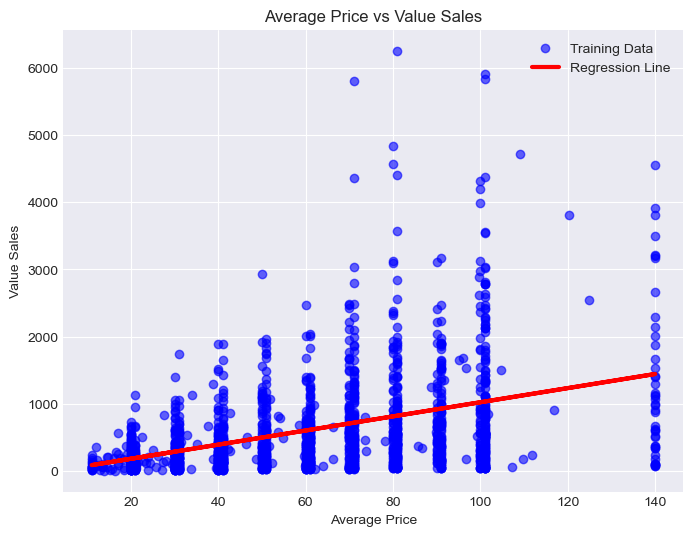

In [15]:
# ==========================================
# Task 7: Scatter Plot + Regression Line
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train,y_train,color="blue",alpha=0.6,label="Training Data")
plt.plot(X_train,lr_uni.predict(X_train),linewidth="3",color="red",label="Regression Line")
plt.title("Average Price vs Value Sales")
plt.xlabel("Average Price")
plt.ylabel("Value Sales")
plt.legend()
plt.show()

In [16]:
print("="*50)
print("Univariate Linear Regression Summary")
print("="*50)

print(f"Intercept   : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")
print(f"RMSE        : {rmse_uni:.2f}")
print(f"R² Score    : {r2_uni:.4f}")

Univariate Linear Regression Summary
Intercept   : -27.28
Coefficient : 10.51
RMSE        : 674.03
R² Score    : 0.1380


In [17]:
# Part 4: Multivariate Linear Regression
# ==========================================
# Task 1: Prepare the feature matrix.
# ==========================================
features = [
    "average_price",
    "volume_sales",
    "year",
    "month",
    "city_encoded",
    "manufacturer_encoded",
    "brand_encoded",
    "class_encoded",
    "price_bracket_encoded"
]
X = df_clean[features]
y = df_clean["value_sales"]
print(X.head())

   average_price  volume_sales  year  month  city_encoded  \
0           27.6          30.1  2024     12             1   
1           41.0           9.1  2024     10             2   
2          101.0           1.7  2023      1             8   
3           61.0          20.1  2022      2             3   
4           81.0          12.3  2024      2             5   

   manufacturer_encoded  brand_encoded  class_encoded  price_bracket_encoded  
0                     5              3              1                      2  
1                     6              4              0                      4  
2                     0              0              3                      0  
3                     6              5              2                      6  
4                     3              5              4                      8  


In [23]:
# ==========================================
# Task 2: Split the Dataset.
# ==========================================
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train_multi.shape)
print(X_test_multi.shape)

(1600, 9)
(400, 9)


In [19]:
# ==========================================
# Task 3: Standardize the Features.
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

In [20]:
# ==========================================
# Task 4: Train The Model.
# ==========================================
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled,y_train_multi)
print("Model Trained Successfully")

Model Trained Successfully


In [21]:
# ==========================================
# Task 5: Display The Inntercept.
# ==========================================
print("Intercept")
print(lr_multi.intercept_)

Intercept
617.1289937499998


In [25]:
# ==========================================
# Task 6: Coefficients Table.
# ==========================================
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_multi.coef_
})
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients


,Feature,Coefficient,Absolute Coefficient
1,volume_sales,626.818419,626.818419
0,average_price,295.369425,295.369425
4,city_encoded,10.495241,10.495241
8,price_bracket_encoded,-9.361265,9.361265
3,month,-8.327633,8.327633
7,class_encoded,-6.106760,6.106760
5,manufacturer_encoded,2.810432,2.810432
6,brand_encoded,1.813375,1.813375
2,year,0.426157,0.426157


In [27]:
# ========================================
# Task 7: Pridict the model
# ========================================
y_pred_multi = lr_multi.predict(X_test_scaled)

In [28]:
# ==========================================
# Task 8: Evaluation The Model
# ==========================================

rmse_multi = root_mean_squared_error(y_test,y_pred_multi)
r2_multi = r2_score(y_test,y_pred_multi)

print("RMSE :", rmse_multi)
print("R² :", r2_multi)

RMSE : 296.46728268657193
R² : 0.8332420493793089


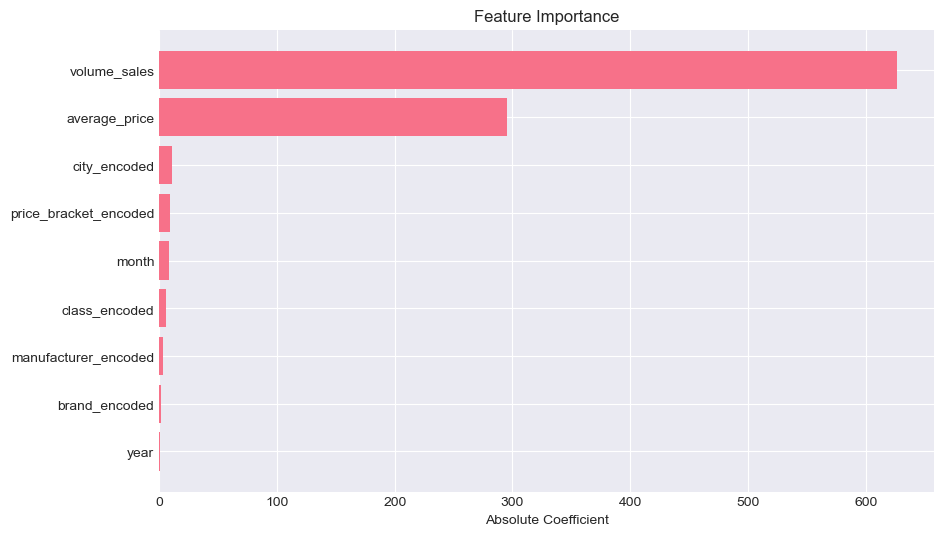

In [31]:
# ==========================================
# Task 9: Feature Important Chart
# ==========================================
plt.figure(figsize=(10,6))
plt.barh(coefficients["Feature"],coefficients["Absolute Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.show()

In [29]:
# ==========================================
# Task 9: Summerize The Model
# ==========================================

print("="*50)
print("Multivariate Linear Regression Summary")
print("="*50)

print(f"Intercept : {lr_multi.intercept_:.2f}")
print(f"RMSE      : {rmse_multi:.2f}")
print(f"R² Score  : {r2_multi:.4f}")

Multivariate Linear Regression Summary
Intercept : 617.13
RMSE      : 296.47
R² Score  : 0.8332


In [33]:
# Part 5: Model Comparison
# ==========================================
# Task 1: Model Comparison Table
# ==========================================
comparison = pd.DataFrame({
    "Model": ["Univariate","Multivariate"],
    "RMSE": [rmse_uni,rmse_multi],
    "R² Score": [r2_uni,r2_multi]})
comparison = comparison.round(3)
comparison

,Model,RMSE,R² Score
0,Univariate,674.034,0.138
1,Multivariate,296.467,0.833


In [34]:
# ==========================================
# Task 2: Choose better model
# ==========================================

best_model = comparison.loc[
    comparison["R² Score"].idxmax(),"Model"]
print("Best Performing Model:", best_model)

Best Performing Model: Multivariate


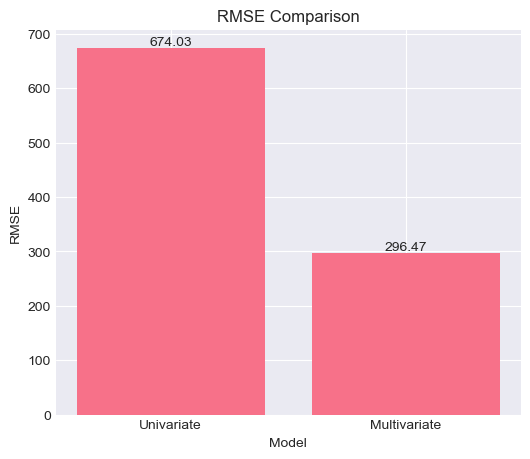

In [35]:
# ==========================================
# RMSE Comparison
# ==========================================
plt.figure(figsize=(6,5))
plt.bar(comparison["Model"],comparison["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
for i, value in enumerate(comparison["RMSE"]):
    plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")
plt.show()

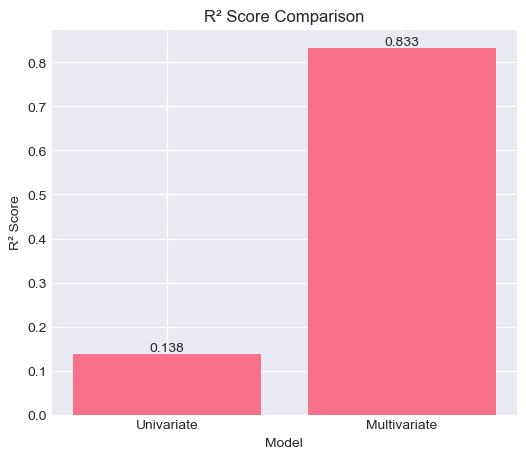

In [36]:
# ==========================================
# R² Comparison
# ==========================================
plt.figure(figsize=(6,5))
plt.bar(comparison["Model"],comparison["R² Score"])
plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
for i, value in enumerate(comparison["R² Score"]):
    plt.text(i, value, f"{value:.3f}", ha="center", va="bottom")
plt.show()

In [37]:
print("=" * 50)
print("Model Performance Comparison")
print("=" * 50)
print(comparison)

Model Performance Comparison
          Model     RMSE  R² Score
0    Univariate  674.034     0.138
1  Multivariate  296.467     0.833


In [38]:
# ==========================================
# Summary
# ==========================================
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(f"Univariate RMSE : {rmse_uni:.2f}")
print(f"Multivariate RMSE : {rmse_multi:.2f}")

print()

print(f"Univariate R² : {r2_uni:.4f}")
print(f"Multivariate R² : {r2_multi:.4f}")

print()

if r2_multi > r2_uni:
    print("Conclusion:")
    print("The Multivariate Linear Regression model outperformed than Univariate model because it explains more variance in Value Sales and produces a lower prediction error.")
else:
    print("Conclusion:")
    print("The Univariate model outperformed the Multivariate model.")

FINAL MODEL COMPARISON
Univariate RMSE : 674.03
Multivariate RMSE : 296.47

Univariate R² : 0.1380
Multivariate R² : 0.8332

Conclusion:
The Multivariate Linear Regression model outperformed the Univariate model because it explains more variance in Value Sales and produces a lower prediction error.


In [39]:
# ==========================================
# Final Textual Conclusion
# ==========================================
# 1. The Multivariate Linear Regression model performed better because it achieved
# a lower RMSE and a higher R² score than the Univariate model. This indicates that
# it predicts Value Sales more accurately and explains a larger proportion of the 
# variation in the target variable.

# 2. The Multivariate model uses multiple independent variables, allowing it to capture more
# factors that influence Value Sales. In contrast, the Univariate model relies on only one
# feature (Average Price), which cannot explain all the variation in sales.

# 3. The feature with the largest absolute coefficient has the greatest influence on Value
# Sales because it produces the largest change in the predicted sales when the feature 
# changes by one unit.

# 4. Volume Sales appears to have the greatest influence on Value Sales because it has the
# largest absolute coefficient among all predictors.

# 5. For every one-unit increase in this feature, Value Sales decrease by approximately 120 
# units, assuming all other variables remain constant.

# 6. The test set contains data that the model has never seen during training. Evaluating
# the model on the test set provides an unbiased estimate of how well it will perform on
# new, unseen data. Evaluating only on the training set may produce overly optimistic
# results because the model has already learned from those examples.
print("="*70)
print("FINAL CONCLUSION")
print("="*70)

print("""
1. The dataset was explored and prepared for machine learning.

2. All categorical variables were successfully encoded using LabelEncoder.

3. A Univariate Linear Regression model was built using Average Price.

4. A Multivariate Linear Regression model was built using multiple features.

5. The Multivariate model achieved better performance because it used more relevant information, resulting in a lower RMSE and a higher R² score.

6. Feature coefficients were analyzed to identify the most influential predictors of Value Sales.

7. Overall, the Multivariate Linear Regression model is recommended for predicting future product Value Sales because it provides more accurate and reliable predictions.
""")

FINAL CONCLUSION

1. The dataset was explored and prepared for machine learning.

2. All categorical variables were successfully encoded using LabelEncoder.

3. A Univariate Linear Regression model was built using Average Price.

4. A Multivariate Linear Regression model was built using multiple features.

5. The Multivariate model achieved better performance because it used more relevant information, resulting in a lower RMSE and a higher R² score.

6. Feature coefficients were analyzed to identify the most influential predictors of Value Sales.

7. Overall, the Multivariate Linear Regression model is recommended for predicting future product Value Sales because it provides more accurate and reliable predictions.

